# DDPM

### Author: Ashish Lama

Prompt Used:
1. I have a given set of preprocessed images on a file location how do I model a DDPM model?
2. Can I continue my training from the last checkpoint that is saved?

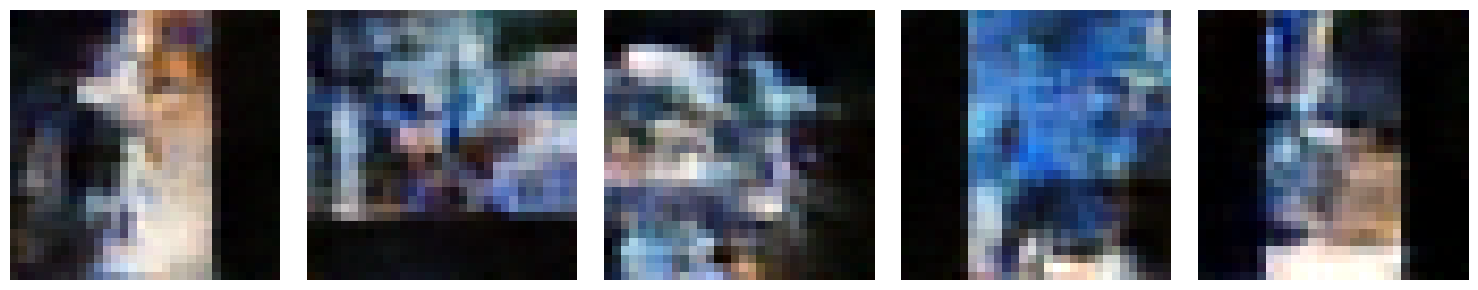

In [ ]:
save_and_plot_top_k_samples(u_samples, top_k=5, save_dir="../model-images/DDPM")

Importing Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance
from collections import defaultdict
import os
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import save_image
import torch
import torch.nn as nn
import math
import os
from torchvision.utils import save_image
import os
from torchvision.utils import save_image
from pytorch_fid.fid_score import calculate_fid_given_paths

Getting the file path for images

In [13]:
root_path = '../data/final_processed_data/'
train_path = root_path + 'train'
val_path   = root_path + 'val'
test_path  = root_path + 'test'

Taking a balanced subset of 500 sample images from each class

In [23]:
def get_balanced_subset(dataset, n_per_class=500):
    class_indices = defaultdict(list)
    # This efficiently iterates filepaths/labels without loading images
    for idx, (path, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)
    selected_indices = []
    for label, indices in class_indices.items():
        np.random.shuffle(indices)
        selected_indices.extend(indices[:n_per_class])
    return Subset(dataset, selected_indices)

In [24]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Or your actual image size
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

In [25]:
train_dataset = ImageFolder(train_path, transform=transform)
val_dataset   = ImageFolder(val_path,   transform=transform)
test_dataset  = ImageFolder(test_path,  transform=transform)

train_subset = get_balanced_subset(train_dataset, n_per_class=500)
val_subset   = get_balanced_subset(val_dataset,   n_per_class=500)
test_subset  = get_balanced_subset(test_dataset,  n_per_class=500)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_subset,  batch_size=64, shuffle=False)

In [26]:
class DiffusionScheduler:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

    def q_sample(self, x0, t, noise):
        sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod[t]).view(-1, 1, 1, 1)
        sqrt_one_minus = torch.sqrt(1 - self.alphas_cumprod[t]).view(-1, 1, 1, 1)
        return sqrt_alphas_cumprod * x0 + sqrt_one_minus * noise

    def p_sample(self, model, x, t):
        pred_noise = model(x, torch.full((x.shape[0],), t, dtype=torch.long))
        alpha = self.alphas[t]
        alpha_cumprod = self.alphas_cumprod[t]
        beta = self.betas[t]
        noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)
        return (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * pred_noise) + torch.sqrt(beta) * noise

In [64]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = time[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.1):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, out_channels),
            nn.SiLU()
        )
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Dropout(dropout)
        )
        self.res_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t):
        h = self.block1(x)
        time_emb = self.time_mlp(t)[:, :, None, None]
        h = h + time_emb
        h = self.block2(h)
        return h + self.res_conv(x)

class UNet(nn.Module):
    def __init__(self, img_channels=3, base_channels=64, time_emb_dim=256):
        super().__init__()
        self.time_embedding = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        # Encoder
        self.conv_in = nn.Conv2d(img_channels, base_channels, 3, padding=1)
        self.down1 = ResidualBlock(base_channels, base_channels*2, time_emb_dim)
        self.down2 = ResidualBlock(base_channels*2, base_channels*4, time_emb_dim)
        self.down3 = ResidualBlock(base_channels*4, base_channels*8, time_emb_dim)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ResidualBlock(base_channels*8, base_channels*8, time_emb_dim)

        # Decoder (CHANNELS ARE CORRECT)
        self.up3 = nn.ConvTranspose2d(base_channels*8, base_channels*4, 2, stride=2)            # 512→256
        self.dec3 = ResidualBlock(base_channels*4 + base_channels*8, base_channels*4, time_emb_dim)  # 256+512=768→256

        self.up2 = nn.ConvTranspose2d(base_channels*4, base_channels*2, 2, stride=2)            # 256→128
        self.dec2 = ResidualBlock(base_channels*2 + base_channels*4, base_channels*2, time_emb_dim)  # 128+256=384→128

        self.up1 = nn.ConvTranspose2d(base_channels*2, base_channels, 2, stride=2)              # 128→64
        self.dec1 = ResidualBlock(base_channels + base_channels*2, base_channels, time_emb_dim)      # 64+128=192→64

        self.conv_out = nn.Conv2d(base_channels, img_channels, 1)

    def forward(self, x, t):
        t_emb = self.time_embedding(t)

        x1 = self.conv_in(x)
        x2 = self.down1(x1, t_emb)
        x3 = self.pool(x2)
        x3 = self.down2(x3, t_emb)
        x4 = self.pool(x3)
        x4 = self.down3(x4, t_emb)
        x5 = self.pool(x4)

        bottleneck = self.bottleneck(x5, t_emb)

        d3 = self.up3(bottleneck)
        d3 = torch.cat([d3, x4], dim=1)
        d3 = self.dec3(d3, t_emb)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, x3], dim=1)
        d2 = self.dec2(d2, t_emb)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, x2], dim=1)
        d1 = self.dec1(d1, t_emb)

        out = self.conv_out(d1)
        return out


Helper function to save the model in every 10th checkpoint

In [45]:
def save_checkpoint(model, optimizer, epoch, loss, filename="ddpm_checkpoint.pth", checkpoint_dir="./checkpoints/"):
    os.makedirs(checkpoint_dir, exist_ok=True)  # Ensure directory exists
    filepath = os.path.join(checkpoint_dir, filename)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, filepath)

Helper function to train the model

In [46]:
def train_ddpm(
    model,
    scheduler,
    dataloader,
    epochs=1,
    lr=2e-4,
    optimizer=None,
    start_epoch=0,
    checkpoint_prefix="ddpm_checkpoint",
    checkpoint_dir="../checkpoints/"
):
    import torch
    import torch.optim as optim
    from tqdm import tqdm
    import os

    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    
    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}")
        for x0, _ in pbar:
            t = torch.randint(0, scheduler.T, (x0.size(0),)).long()
            noise = torch.randn_like(x0)
            x_t = scheduler.q_sample(x0, t, noise)
            pred_noise = model(x_t, t)
            loss = loss_fn(pred_noise, noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix(loss=loss.item())
            avg_loss = running_loss / len(dataloader)
        
        # SAVE EVERY 10 EPOCHS AND LAST EPOCH
        if ((epoch + 1) % 10 == 0) or ((epoch + 1) == epochs):
            save_checkpoint(
                model, optimizer, epoch+1, avg_loss, filename=f"{checkpoint_prefix}_epoch{epoch+1}.pth",
                checkpoint_dir=checkpoint_dir
            )
            print(f"Checkpoint saved for epoch {epoch+1}. Avg loss: {avg_loss:.4f}")


Helper function to get the given number of samples of image generated by model

In [30]:
@torch.no_grad()
def sample_ddpm(model, scheduler, n=16, img_shape=(3, 32, 32)):
    model.eval()
    x = torch.randn(n, *img_shape)
    for t in reversed(range(scheduler.T)):
        x = scheduler.p_sample(model, x, t)
    x = (x.clamp(-1, 1) + 1) / 2
    return x

Initializing the model

In [32]:
scheduler = DiffusionScheduler(T=1000, beta_start=1e-4, beta_end=0.02)

In [42]:
u_model = UNet(img_channels=3, base_channels=32, time_emb_dim=128)
optimizer = torch.optim.Adam(u_model.parameters(), lr=2e-4)

Training the model

In [47]:
start_epoch=0
train_ddpm(
    model=u_model,
    scheduler=scheduler,
    dataloader=train_loader,
    epochs=100,                
    lr=2e-4,
    optimizer=optimizer,
    start_epoch=start_epoch,
    checkpoint_prefix="ddpm_checkpoint",
    checkpoint_dir="../model/checkpoint"
)


Epoch 10: 100%|██████████| 32/32 [05:00<00:00,  9.39s/it, loss=0.0517]


Checkpoint saved for epoch 10. Avg loss: 0.0605


Epoch 20: 100%|██████████| 32/32 [03:31<00:00,  6.60s/it, loss=0.0711]


Checkpoint saved for epoch 20. Avg loss: 0.0476


Epoch 30: 100%|██████████| 32/32 [03:29<00:00,  6.56s/it, loss=0.0483]


...

Checkpoint saved for epoch 80. Avg loss: 0.0301


Epoch 90: 100%|██████████| 32/32 [02:57<00:00,  5.54s/it, loss=0.0219]


Checkpoint saved for epoch 90. Avg loss: 0.0332


Epoch 100: 100%|██████████| 32/32 [02:58<00:00,  5.57s/it, loss=0.051] 

Checkpoint saved for epoch 100. Avg loss: 0.0331


Generating 64 samples of image generated by the model

In [48]:
u_samples = sample_ddpm(u_model, scheduler, n=64, img_shape=(3, 32, 32))

Plotting the generated image

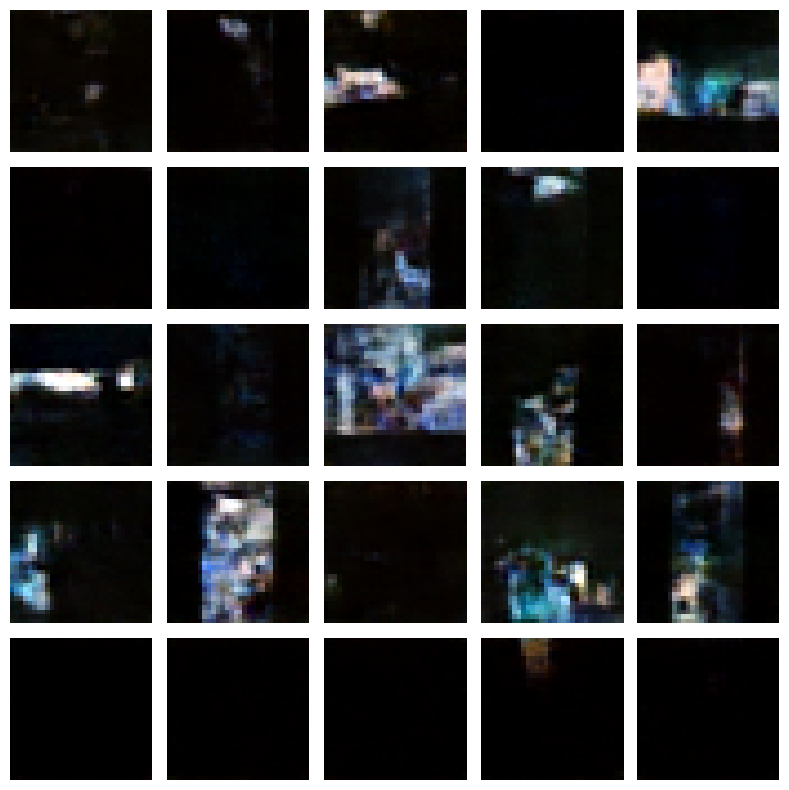

In [ ]:
plt.figure(figsize=(8,8))
for i in range(25):
    img = u_samples[i]
    img = img.permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.tight_layout()
plt.show()

Helper function to save generated image to calculate **FID**

In [ ]:
def save_images_to_folder(images, folder):
    os.makedirs(folder, exist_ok=True)
    for i, img in enumerate(images):
        # img: torch tensor, shape [3, 64, 64], assumed [-1,1] or [0,1]
        img = (img + 1) / 2 if img.min() < 0 else img  # bring [-1,1] to [0,1]
        save_image(img, os.path.join(folder, f"gen_{i:04d}.png"))

# Generate and save images
generated_images = sample_ddpm(u_model, scheduler, n=100, img_shape=(3, 64, 64))
save_images_to_folder(generated_images, "./fid_generated")

In [52]:
def save_real_images_from_loader(loader, folder, n=100):
    os.makedirs(folder, exist_ok=True)
    saved = 0
    for imgs, _ in loader:
        for img in imgs:
            if saved >= n:
                break
            img = (img + 1) / 2 if img.min() < 0 else img
            save_image(img, os.path.join(folder, f"real_{saved:04d}.png"))
            saved += 1
        if saved >= n:
            break

save_real_images_from_loader(val_loader, "./fid_real", n=100)

Calculating the **Fréchet inception distance (FID)**

In [ ]:
paths = ["./fid_real", "./fid_generated"]
fid_value = calculate_fid_given_paths(paths, batch_size=32, device='cpu', dims=2048)
print("FID:", fid_value)

100%|██████████| 4/4 [00:20<00:00,  5.11s/it]


FID: 279.23901216537877


**FID: 279.239**

Helper function to calculate **Inception Score**

In [ ]:
inception_model = InceptionV3(include_top=True, weights='imagenet', pooling='avg')

def calculate_inception_score(images, splits=10):
    images = images.detach().cpu().numpy()
    N = images.shape[0]
    images = np.transpose(images, (0, 2, 3, 1))
    images = np.clip(images * 255, 0, 255).astype(np.uint8)
    images_tf = tf.convert_to_tensor(images)
    images_tf = tf.image.resize(images_tf, (299, 299))
    images_tf = preprocess_input(tf.cast(images_tf, tf.float32))

    # Predict in batches to avoid memory error for large N
    batch_size = 64
    preds = []
    for i in range(0, N, batch_size):
        batch_preds = inception_model.predict(images_tf[i:i+batch_size], verbose=0)
        preds.append(batch_preds)
    preds = np.vstack(preds)
    preds = tf.nn.softmax(preds).numpy()

    split_scores = []
    for k in range(splits):
        part = preds[k * N // splits: (k + 1) * N // splits]
        py = np.mean(part, axis=0)
        scores = [entropy(p, py) for p in part]
        split_scores.append(np.exp(np.mean(scores)))
    return float(np.mean(split_scores)), float(np.std(split_scores))

Calculating **Inception Score (IS)**

In [63]:
if u_samples.min() < 0:
    u_samples = (u_samples + 1) / 2
u_samples = u_samples.clamp(0, 1)

mean_is, std_is = calculate_inception_score(u_samples, splits=5)
print(f"Inception Score (IS): {mean_is:.4f} ± {std_is:.4f}")

Inception Score (IS): 1.0000 ± 0.0000


**Inception Score (IS): 1.0000 ± 0.0000**

Generating and displaying 5 images generated by the model

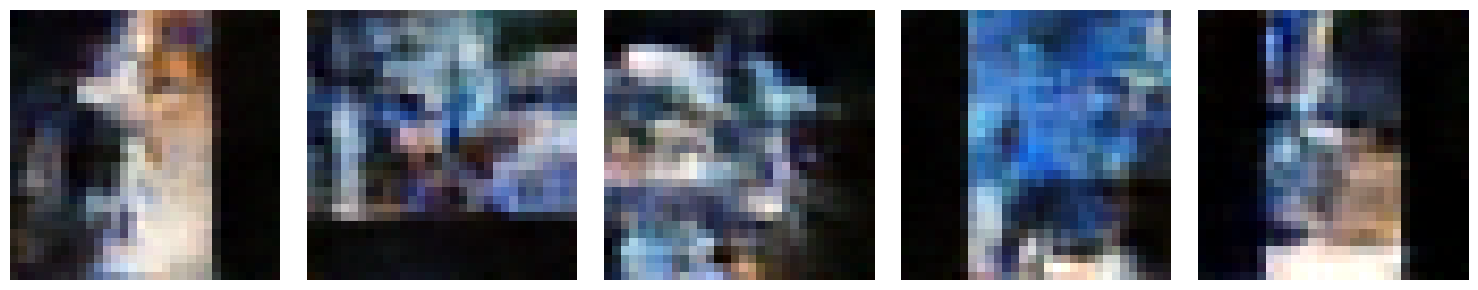

In [ ]:
def save_and_plot_top_k_samples(samples, top_k=5, save_dir="../model-images/DDPM"):
    # Compute mean pixel value for each sample (to select the "best")
    means = samples.view(samples.shape[0], -1).mean(dim=1)
    best_idx = torch.topk(means, top_k).indices

    os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=(3 * top_k, 3))
    for i, idx in enumerate(best_idx):
        img = samples[idx]
        # Plot
        plt.subplot(1, top_k, i + 1)
        plt.imshow(np.clip(img.permute(1, 2, 0).numpy(), 0, 1))
        plt.axis('off')
        # Save as PNG
        save_image(img, os.path.join(save_dir, f"sample_{i+1}.png"))
    plt.tight_layout()
    plt.show()

save_and_plot_top_k_samples(u_samples, top_k=5, save_dir="../model-images/DDPM")


# Empirical Hyperparameter tuning

### Author: Om Kiranbhai Patel

- First Prompt: how to do tuning for DDPM model
- Last Prompt: how to add checkpoints and how to generate images and save them


In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from collections import defaultdict
import numpy as np
from tqdm import tqdm
import os
import math
import matplotlib.pyplot as plt
from torchvision.utils import save_image

In [2]:
# Define paths (using your local dataset path)
root_path = r'C:\Users\Meet\Desktop\Yelp2\final_processed_data\\'
train_path = root_path + 'train'
val_path = root_path + 'val'
test_path = root_path + 'test'

In [3]:
# Data preparation (optimized for speed and low memory)
def get_balanced_subset(dataset, n_per_class=200):
    class_indices = defaultdict(list)
    for idx, (path, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)
    selected_indices = []
    for label, indices in class_indices.items():
        np.random.shuffle(indices)
        selected_indices.extend(indices[:n_per_class])
    return Subset(dataset, selected_indices)

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

In [4]:
# Load datasets (only train for tuning)
train_dataset = ImageFolder(train_path, transform=transform)
train_subset = get_balanced_subset(train_dataset, n_per_class=200)
train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, num_workers=0)

In [5]:
# Diffusion Scheduler
class DiffusionScheduler:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

    def q_sample(self, x0, t, noise):
        sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod[t]).view(-1, 1, 1, 1)
        sqrt_one_minus = torch.sqrt(1 - self.alphas_cumprod[t]).view(-1, 1, 1, 1)
        return sqrt_alphas_cumprod * x0 + sqrt_one_minus * noise

    def p_sample(self, model, x, t):
        pred_noise = model(x, torch.full((x.shape[0],), t, dtype=torch.long).to(x.device))
        alpha = self.alphas[t]
        alpha_cumprod = self.alphas_cumprod[t]
        beta = self.betas[t]
        noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)
        return (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * pred_noise) + torch.sqrt(beta) * noise

In [6]:
# UNet model components
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = time[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.1):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, out_channels),
            nn.SiLU()
        )
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Dropout(dropout)
        )
        self.res_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t):
        h = self.block1(x)
        time_emb = self.time_mlp(t)[:, :, None, None]
        h = h + time_emb
        h = self.block2(h)
        return h + self.res_conv(x)

class UNet(nn.Module):
    def __init__(self, img_channels=3, base_channels=32, time_emb_dim=128):
        super().__init__()
        self.time_embedding = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )
        self.conv_in = nn.Conv2d(img_channels, base_channels, 3, padding=1)
        self.down1 = ResidualBlock(base_channels, base_channels*2, time_emb_dim)
        self.down2 = ResidualBlock(base_channels*2, base_channels*4, time_emb_dim)
        self.down3 = ResidualBlock(base_channels*4, base_channels*8, time_emb_dim)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ResidualBlock(base_channels*8, base_channels*8, time_emb_dim)
        self.up3 = nn.ConvTranspose2d(base_channels*8, base_channels*4, 2, stride=2)
        self.dec3 = ResidualBlock(base_channels*4 + base_channels*8, base_channels*4, time_emb_dim)
        self.up2 = nn.ConvTranspose2d(base_channels*4, base_channels*2, 2, stride=2)
        self.dec2 = ResidualBlock(base_channels*2 + base_channels*4, base_channels*2, time_emb_dim)
        self.up1 = nn.ConvTranspose2d(base_channels*2, base_channels, 2, stride=2)
        self.dec1 = ResidualBlock(base_channels + base_channels*2, base_channels, time_emb_dim)
        self.conv_out = nn.Conv2d(base_channels, img_channels, 1)

    def forward(self, x, t):
        t_emb = self.time_embedding(t)
        x1 = self.conv_in(x)
        x2 = self.down1(x1, t_emb)
        x3 = self.pool(x2)
        x3 = self.down2(x3, t_emb)
        x4 = self.pool(x3)
        x4 = self.down3(x4, t_emb)
        x5 = self.pool(x4)
        bottleneck = self.bottleneck(x5, t_emb)
        d3 = self.up3(bottleneck)
        d3 = torch.cat([d3, x4], dim=1)
        d3 = self.dec3(d3, t_emb)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, x3], dim=1)
        d2 = self.dec2(d2, t_emb)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, x2], dim=1)
        d1 = self.dec1(d1, t_emb)
        out = self.conv_out(d1)
        return out

In [25]:
# Checkpoint saving function
def save_checkpoint(model, optimizer, epoch, loss, filename, checkpoint_dir=r"C:\Users\Meet\Desktop\Yelp2\final_processed_data\CV-4\checkpoints"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    filepath = os.path.join(checkpoint_dir, filename)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, filepath)

In [27]:
# Training function
def train_ddpm(model, scheduler, dataloader, epochs=50, lr=2e-4, device='cpu'):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    losses = []
    
    model.to(device)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        for x0, _ in pbar:
            x0 = x0.to(device)
            t = torch.randint(0, scheduler.T, (x0.size(0),)).long().to(device)
            noise = torch.randn_like(x0).to(device)
            x_t = scheduler.q_sample(x0, t, noise)
            pred_noise = model(x_t, t)
            loss = loss_fn(pred_noise, noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix(loss=loss.item())
        avg_loss = running_loss / len(dataloader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.4f}")
        save_checkpoint(model, optimizer, epoch+1, avg_loss, f"ddpm_iter{iteration}_epoch{epoch+1}.pth")
    return sum(losses) / len(losses)

In [28]:
# Sampling function
@torch.no_grad()
def sample_ddpm(model, scheduler, n=16, img_shape=(3, 64, 64)):
    model.eval()
    x = torch.randn(n, *img_shape).to(device)
    for t in reversed(range(scheduler.T)):
        x = scheduler.p_sample(model, x, t)
    x = (x.clamp(-1, 1) + 1) / 2
    return x

In [29]:
# Image saving and plotting function
def save_and_plot_top_k_samples(samples, top_k=5, save_dir=r"C:\Users\Meet\Desktop\Yelp2\final_processed_data\CV-4\Tunned-Images"):
    means = samples.view(samples.shape[0], -1).mean(dim=1)
    best_idx = torch.topk(means, top_k).indices
    os.makedirs(save_dir, exist_ok=True)
    plt.figure(figsize=(3 * top_k, 3))
    for i, idx in enumerate(best_idx):
        img = samples[idx]
        plt.subplot(1, top_k, i + 1)
        plt.imshow(np.clip(img.permute(1, 2, 0).numpy(), 0, 1))
        plt.axis('off')
        save_image(img, os.path.join(save_dir, f"sample_{i+1}.png"))
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "top_samples.png"))
    plt.close()

In [30]:
# Device setup
device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


In [33]:
# Iteration 1: Initial hyperparameter search
print("\n=== Iteration 1: Initial Hyperparameter Search ===")
hyperparams_iter1 = [
    {'lr': 1e-4, 'T': 500},
    {'lr': 2e-4, 'T': 1000},
]
results_iter1 = []
best_loss_iter1 = float('inf')
best_params_iter1 = None
iteration = 1

for params in hyperparams_iter1:
    print(f"\nTesting: lr={params['lr']}, T={params['T']}")
    model = UNet(img_channels=3, base_channels=32, time_emb_dim=128)
    scheduler = DiffusionScheduler(T=params['T'], beta_start=1e-4, beta_end=0.02)
    avg_loss = train_ddpm(model, scheduler, train_loader, epochs=10, lr=params['lr'], device=device)
    results_iter1.append({'lr': params['lr'], 'T': params['T'], 'avg_loss': avg_loss})
    if avg_loss < best_loss_iter1:
        best_loss_iter1 = avg_loss
        best_params_iter1 = params
        print(f"New best parameters (Iter 1): lr={best_params_iter1['lr']}, T={best_params_iter1['T']}, Avg Loss: {best_loss_iter1:.4f}")

print("\nIteration 1 Results:")
for result in results_iter1:
    print(f"lr={result['lr']}, T={result['T']}, Avg Loss: {result['avg_loss']:.4f}")
print(f"Best Parameters (Iter 1): lr={best_params_iter1['lr']}, T={best_params_iter1['T']}, Avg Loss: {best_loss_iter1:.4f}")


=== Iteration 1: Initial Hyperparameter Search ===

Testing: lr=0.0001, T=500


Epoch 1/10: 100%|██████████| 50/50 [05:45<00:00,  6.90s/it, loss=0.259]


Epoch 1/10, Avg Loss: 0.5337


Epoch 2/10: 100%|██████████| 50/50 [04:53<00:00,  5.86s/it, loss=0.185]


Epoch 2/10, Avg Loss: 0.2066


...

Epoch 8/10, Avg Loss: 0.0610


Epoch 9/10: 100%|██████████| 50/50 [02:55<00:00,  3.51s/it, loss=0.0302]


Epoch 9/10, Avg Loss: 0.0627


Epoch 10/10: 100%|██████████| 50/50 [02:56<00:00,  3.53s/it, loss=0.0841]

Epoch 10/10, Avg Loss: 0.0615
New best parameters (Iter 1): lr=0.0002, T=1000, Avg Loss: 0.1057

Iteration 1 Results:
lr=0.0001, T=500, Avg Loss: 0.1655
lr=0.0002, T=1000, Avg Loss: 0.1057
Best Parameters (Iter 1): lr=0.0002, T=1000, Avg Loss: 0.1057


In [34]:
# Iteration 2:

print("\nIteration 2 Results:")
print("\n=== Iteration 2: Refined Hyperparameter Search ===")
# Refine lr (±50% of best from Iter 1) and test a new T value
best_lr = best_params_iter1['lr']
hyperparams_iter2 = [
    {'lr': best_lr * 0.5, 'T': best_params_iter1['T']},  # Lower lr
    {'lr': best_lr * 1.5, 'T': 750 if best_params_iter1['T'] == 500 else 500},  # Higher lr, different T
]
results_iter2 = []
best_loss = best_loss_iter1
best_params = best_params_iter1
iteration = 2

for params in hyperparams_iter2:
    print(f"\nTesting: lr={params['lr']}, T={params['T']}")
    model = UNet(img_channels=3, base_channels=32, time_emb_dim=128)
    scheduler = DiffusionScheduler(T=params['T'], beta_start=1e-4, beta_end=0.02)
    avg_loss = train_ddpm(model, scheduler, train_loader, epochs=10, lr=params['lr'], device=device)
    results_iter2.append({'lr': params['lr'], 'T': params['T'], 'avg_loss': avg_loss})
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_params = params
        print(f"New best parameters (Iter 2): lr={best_params['lr']}, T={best_params['T']}, Avg Loss: {best_loss:.4f}")

print("\nIteration 2 Results:")
for result in results_iter2:
    print(f"lr={result['lr']}, T={result['T']}, Avg Loss: {result['avg_loss']:.4f}")
print(f"\nFinal Best Parameters: lr={best_params['lr']}, T={best_params['T']}, Avg Loss: {best_loss:.4f}")


Iteration 2 Results:

=== Iteration 2: Refined Hyperparameter Search ===

Testing: lr=0.0001, T=1000


Epoch 1/10: 100%|██████████| 50/50 [03:00<00:00,  3.61s/it, loss=0.29] 


Epoch 1/10, Avg Loss: 0.5187


Epoch 2/10: 100%|██████████| 50/50 [03:21<00:00,  4.03s/it, loss=0.222]


Epoch 2/10, Avg Loss: 0.1910


...

Epoch 8/10, Avg Loss: 0.0726


Epoch 9/10: 100%|██████████| 50/50 [02:55<00:00,  3.52s/it, loss=0.0881]


Epoch 9/10, Avg Loss: 0.0719


Epoch 10/10: 100%|██████████| 50/50 [02:55<00:00,  3.51s/it, loss=0.0838]

Epoch 10/10, Avg Loss: 0.0775

Iteration 2 Results:
lr=0.0001, T=1000, Avg Loss: 0.1483
lr=0.00030000000000000003, T=500, Avg Loss: 0.1176

Final Best Parameters: lr=0.0002, T=1000, Avg Loss: 0.1057


In [35]:
# Train and save the best model
print("\n=== Training Best Model ===")
checkpoint_dir = r'C:\Users\Meet\Desktop\Yelp2\final_processed_data\CV-4\checkpoints'
model = UNet(img_channels=3, base_channels=32, time_emb_dim=128)
scheduler = DiffusionScheduler(T=best_params['T'], beta_start=1e-4, beta_end=0.02)
optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
model.to(device)
iteration = 'final'
train_ddpm(model, scheduler, train_loader, epochs=100, lr=best_params['lr'], device=device)
save_checkpoint(model, optimizer, 10, best_loss, "ddpm_best_model.pth")
print(f"Best model saved as '{os.path.join(checkpoint_dir, 'ddpm_best_model.pth')}'")


=== Training Best Model ===


Epoch 1/100: 100%|██████████| 50/50 [03:02<00:00,  3.66s/it, loss=0.189]


Epoch 1/100, Avg Loss: 0.3827


Epoch 2/100: 100%|██████████| 50/50 [03:04<00:00,  3.68s/it, loss=0.111] 


Epoch 2/100, Avg Loss: 0.1395


...

Epoch 98/100, Avg Loss: 0.0299


Epoch 99/100: 100%|██████████| 50/50 [02:43<00:00,  3.27s/it, loss=0.0188] 


Epoch 99/100, Avg Loss: 0.0278


Epoch 100/100: 100%|██████████| 50/50 [02:46<00:00,  3.33s/it, loss=0.0333] 

Epoch 100/100, Avg Loss: 0.0317
Best model saved as 'C:\Users\Meet\Desktop\Yelp2\final_processed_data\CV-4\checkpoints\ddpm_best_model.pth'


In [36]:
# Generate and save images for the best model
print("\n=== Generating and Saving Images ===")
u_samples = sample_ddpm(model, scheduler, n=16, img_shape=(3, 64, 64))
save_and_plot_top_k_samples(u_samples, top_k=5, save_dir=r"C:\Users\Meet\Desktop\Yelp2\final_processed_data\CV-4\Tunned-Images")
print(r"Generated images saved in C:\Users\Meet\Desktop\Yelp2\final_processed_data\CV-4\Tunned-Images")



=== Generating and Saving Images ===
Generated images saved in C:\Users\Meet\Desktop\Yelp2\final_processed_data\CV-4\Tunned-Images
